In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import os

In [2]:
from src.loader import load_all_samples
from src.filter import filter_data
from src.filter import normalize_and_select_genes
from src.clustering import run_pca
from src.clustering import run_clustering

Is index unique? True
Number of mitochondrial genes detected: 13

QC metrics added to adata.obs:
['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']

QC Statistics:


,total_counts,n_genes_by_counts,pct_counts_mt
count,34078.000000,34078.000000,34078.000000
mean,630.604492,2290.729415,2.499186
std,61.527061,1018.252556,0.938393
min,119.023888,203.000000,0.000000
25%,592.297119,1672.000000,2.106632
50%,633.059692,2122.000000,2.416822
75%,674.417587,2642.000000,2.746958
max,802.334778,10984.000000,40.870228


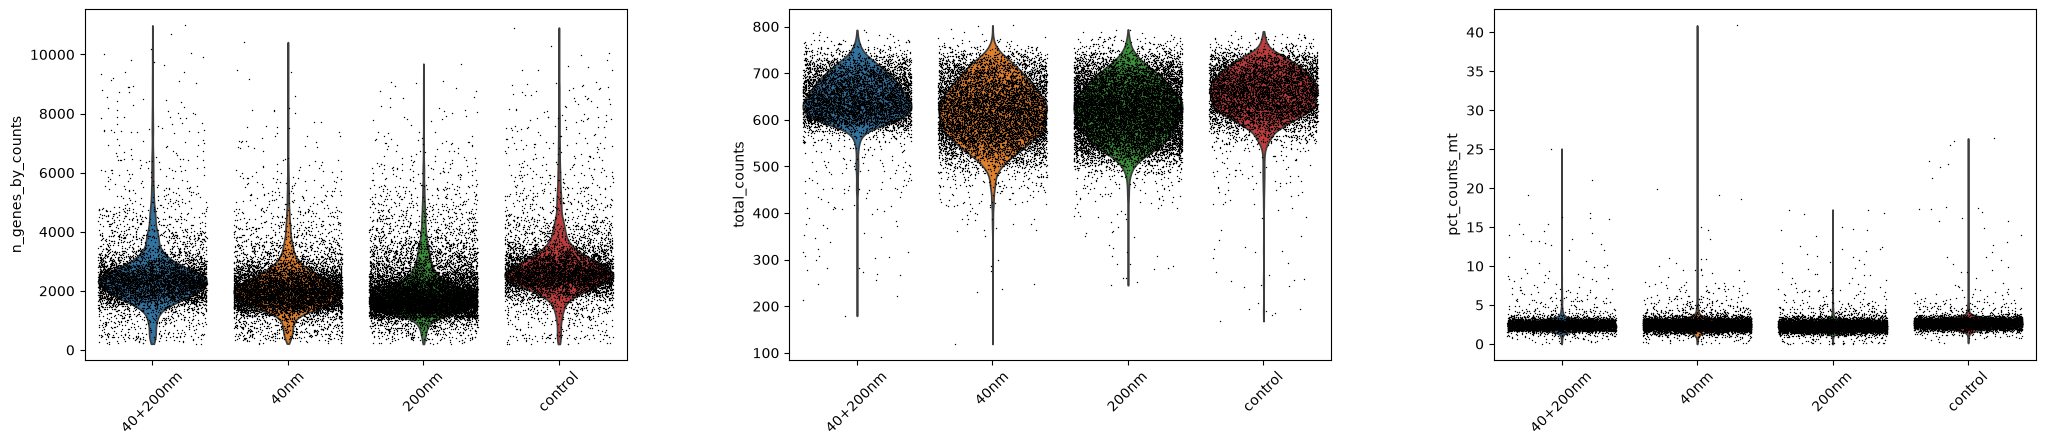

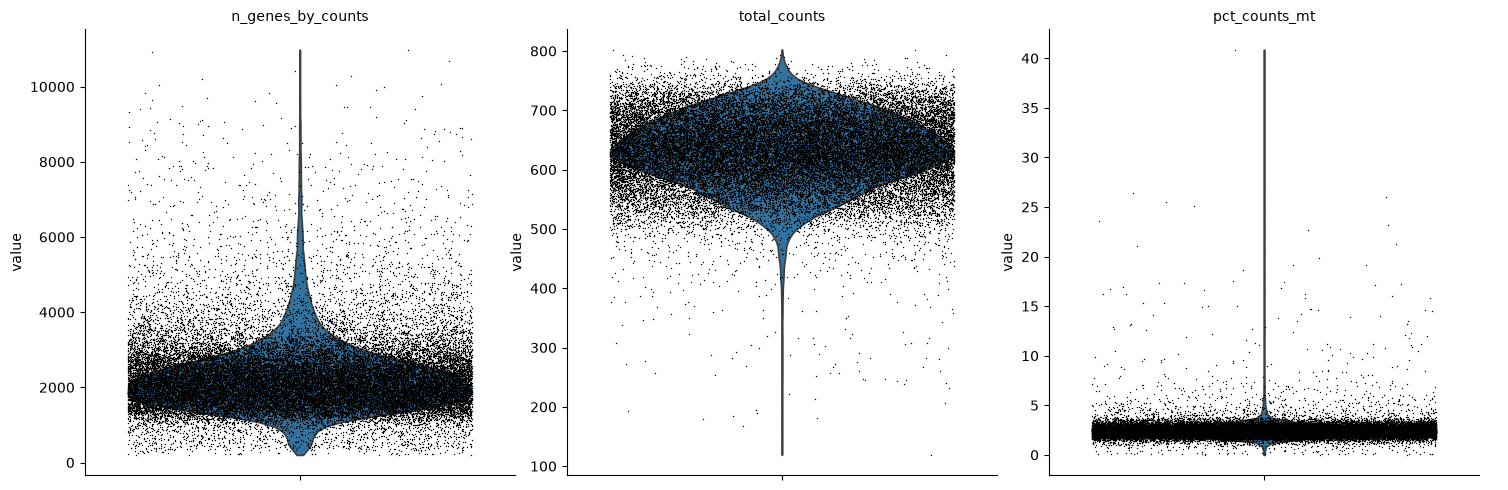

In [3]:
# Read H5AD file
adata = load_all_samples()

print(f"Is index unique? {adata.obs.index.is_unique}")

adata.var['mt'] = adata.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print(f"Number of mitochondrial genes detected: {adata.var['mt'].sum()}")
print(f"\nQC metrics added to adata.obs:")
print([col for col in adata.obs.columns if col.startswith(('total_counts', 'n_genes', 'pct_counts'))])
# Display summary statistics
print("\nQC Statistics:")
qc_stats = adata.obs[['total_counts', 'n_genes_by_counts', 'pct_counts_mt']].describe()
display(qc_stats)

# Calculate QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True, show=False, groupby='sample_id', rotation=45)
plt.savefig('results/qc_scatter_feature.png', bbox_inches='tight')

# Calculate QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True, show=False)
plt.savefig('results/qc_scatter.png',bbox_inches='tight')

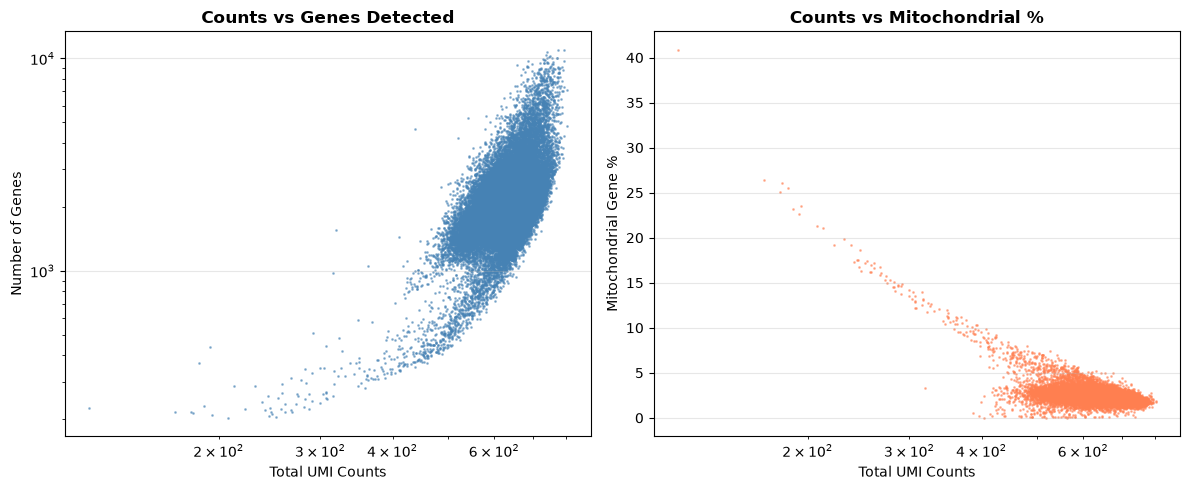


✓ QC scatter plots generated


In [4]:
# Scatter plots to identify outliers and correlations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Total counts vs genes detected
axes[0].scatter(
    adata.obs['total_counts'],
    adata.obs['n_genes_by_counts'],
    alpha=0.5,
    s=1,
    c='steelblue'
)
axes[0].set_xlabel('Total UMI Counts', fontsize=10)
axes[0].set_ylabel('Number of Genes', fontsize=10)
axes[0].set_title('Counts vs Genes Detected', fontsize=12, fontweight='bold')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Total counts vs mitochondrial percentage
axes[1].scatter(
    adata.obs['total_counts'],
    adata.obs['pct_counts_mt'],
    alpha=0.5,
    s=1,
    c='coral'
)
axes[1].set_xlabel('Total UMI Counts', fontsize=10)
axes[1].set_ylabel('Mitochondrial Gene %', fontsize=10)
axes[1].set_title('Counts vs Mitochondrial %', fontsize=12, fontweight='bold')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ QC scatter plots generated")

In [5]:
# Calculate how many cells each gene appears in
gene_occurrence = (adata.X > 0).sum(axis=0)
if hasattr(gene_occurrence, 'A1'): gene_occurrence = gene_occurrence.A1

import pandas as pd
# Create a frequency table for the first 10 values
counts = pd.Series(gene_occurrence).value_counts().sort_index().head(10)

print("Number of cells | Number of genes found in exactly that many cells")
print("----------------|-----------------------------------------------")
print(counts)

Number of cells | Number of genes found in exactly that many cells
----------------|-----------------------------------------------
3     754
4     321
5     171
6     290
7     261
8     195
9     203
10    180
11    159
12    160
Name: count, dtype: int64


In [6]:
adata = filter_data(adata, 500, 4000, 5)

Stats BEFORE filtering: 34078 cells, 24380 genes
Stats AFTER filtering: 31767 cells, 24380 genes


In [7]:
adata = normalize_and_select_genes(adata)

Step 1: Saving raw counts...
Step 2: Normalizing total counts...
Step 3: Log-transforming...
Step 4: Identifying Highly Variable Genes (HVGs)...
Number of HVGs after excluding MT/Ribo: 2487


/usr/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/jovan/Documents/gi/gi-2026/venv/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


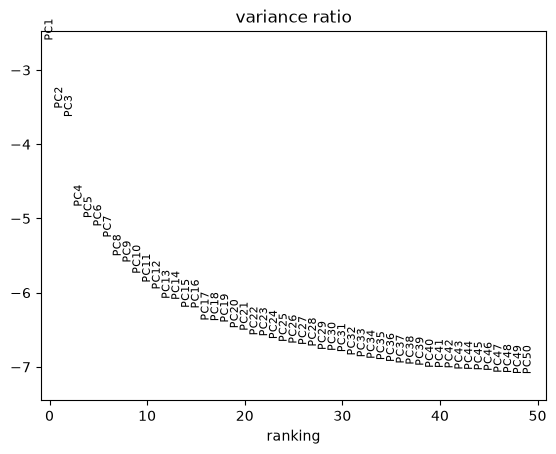

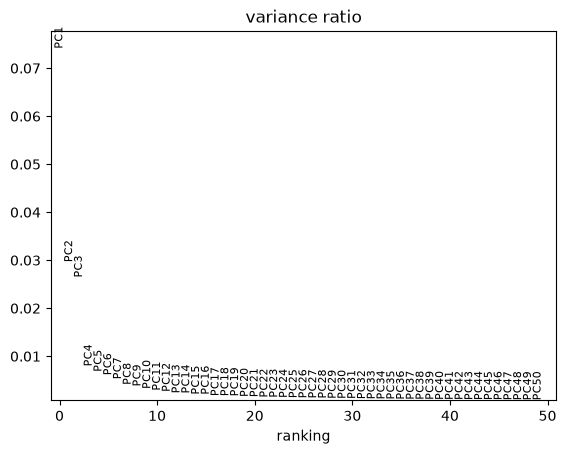

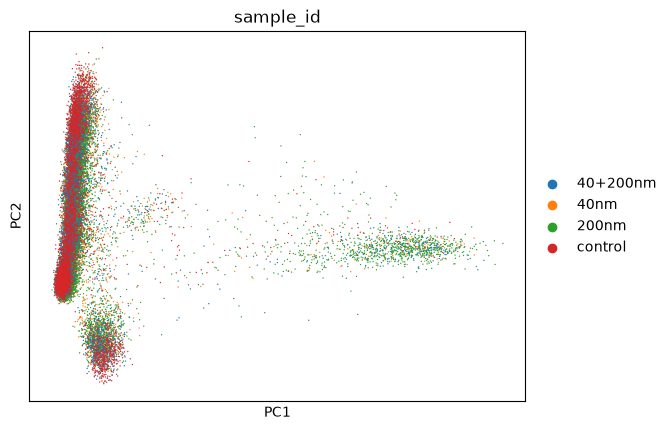

In [8]:
adata = run_pca(adata)

In [9]:
# Calculate variance explained by each PC
variance_ratio = adata.uns['pca']['variance_ratio']
print(f"\nVariance explained by first 10 PCs: {100 * variance_ratio[:10].sum():.2f}%")
print(f"Variance explained by first 30 PCs: {100 * variance_ratio[:30].sum():.2f}%")


Variance explained by first 10 PCs: 16.70%
Variance explained by first 30 PCs: 20.03%


2026-07-31 19:18:11.994328: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-31 19:18:12.194369: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-31 19:18:12.403593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-31 19:18:12.563706: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-31 19:18:12.605118: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-31 19:18:15.222528: W tensorflow/compiler/tf2tensorrt/utils/p

/home/jovan/Documents/gi/gi-2026/src/clustering.py:46: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


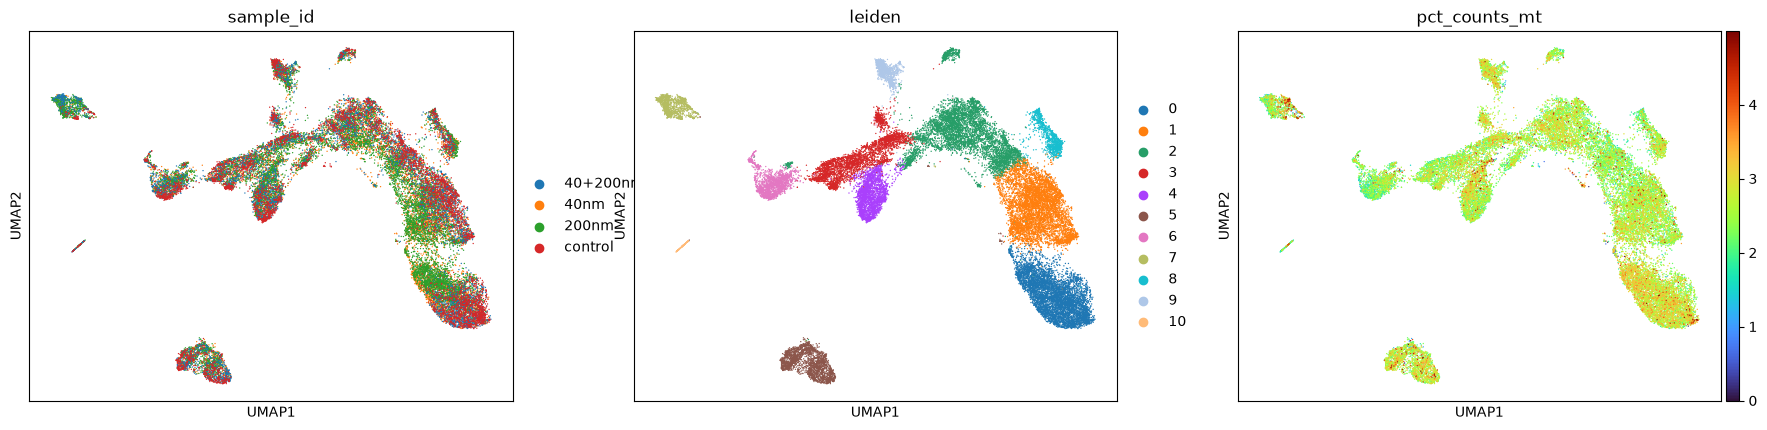

In [10]:
adata = run_clustering(adata, n_pcs=50, resolution=0.5)

n_clusters = adata.obs['leiden'].nunique()

In [11]:
# Find marker genes for Leiden clusters
sc.tl.rank_genes_groups(
    adata,
    groupby='leiden',  # Group by Leiden clusters
    method='wilcoxon',  # Statistical test method - does not assume normal distribution, compares medians rather than mean
    key_added='rank_genes_leiden',
    use_raw=False,
    layer='norm_log'
)

print("✓ Marker genes computed for Leiden clusters")
print(f"  - Method: wilcoxon")
print(f"  - Clusters analyzed: {n_clusters}")

✓ Marker genes computed for Leiden clusters
  - Method: wilcoxon
  - Clusters analyzed: 11


In [12]:
# Overview plot of top marker genes
sc.pl.rank_genes_groups(
    adata,
    n_genes=20,
    sharey=False,
    key='rank_genes_leiden',
    show=False
)

plt.savefig('results/marker_genes.png', bbox_inches='tight')
plt.close()

print("\n✓ Marker genes overview plot generated")


✓ Marker genes overview plot generated


In [13]:
# Extract marker genes as a DataFrame
marker_genes_df = sc.get.rank_genes_groups_df(
    adata,
    group=None,  # Get markers for all groups
    key='rank_genes_leiden'
)

print("\nTop 5 marker genes per cluster:")
print("="*80)

for cluster in sorted(adata.obs['leiden'].unique()):
    cluster_markers = marker_genes_df[
        marker_genes_df['group'] == cluster
    ].head(5)

    print(f"\nCluster {cluster}:")
    for idx, row in cluster_markers.iterrows():
        print(f"  {row['names']:15s} | score: {row['scores']:6.2f} | "
              f"logFC: {row['logfoldchanges']:6.2f} | p-val: {row['pvals']:.2e}")


Top 5 marker genes per cluster:

Cluster 0:
  NELL2           | score:  79.19 | logFC:   2.54 | p-val: 0.00e+00
  THEMIS          | score:  72.50 | logFC:   2.30 | p-val: 0.00e+00
  EEF1B2          | score:  68.88 | logFC:   1.22 | p-val: 0.00e+00
  CCR7            | score:  65.38 | logFC:   1.95 | p-val: 0.00e+00
  LEF1            | score:  64.80 | logFC:   2.11 | p-val: 0.00e+00

Cluster 1:
  EEF1B2          | score:  65.44 | logFC:   1.15 | p-val: 0.00e+00
  LTB             | score:  62.28 | logFC:   1.76 | p-val: 0.00e+00
  ANK3            | score:  60.58 | logFC:   2.22 | p-val: 0.00e+00
  FHIT            | score:  60.52 | logFC:   3.02 | p-val: 0.00e+00
  PLCL1           | score:  59.88 | logFC:   2.25 | p-val: 0.00e+00

Cluster 10:
  ATP10D          | score:  23.30 | logFC:   7.45 | p-val: 4.79e-120
  SIPA1L1         | score:  22.69 | logFC:   4.30 | p-val: 5.75e-114
  GAB2            | score:  22.66 | logFC:   5.12 | p-val: 1.03e-113
  PICALM          | score:  22.43 | logFC: 

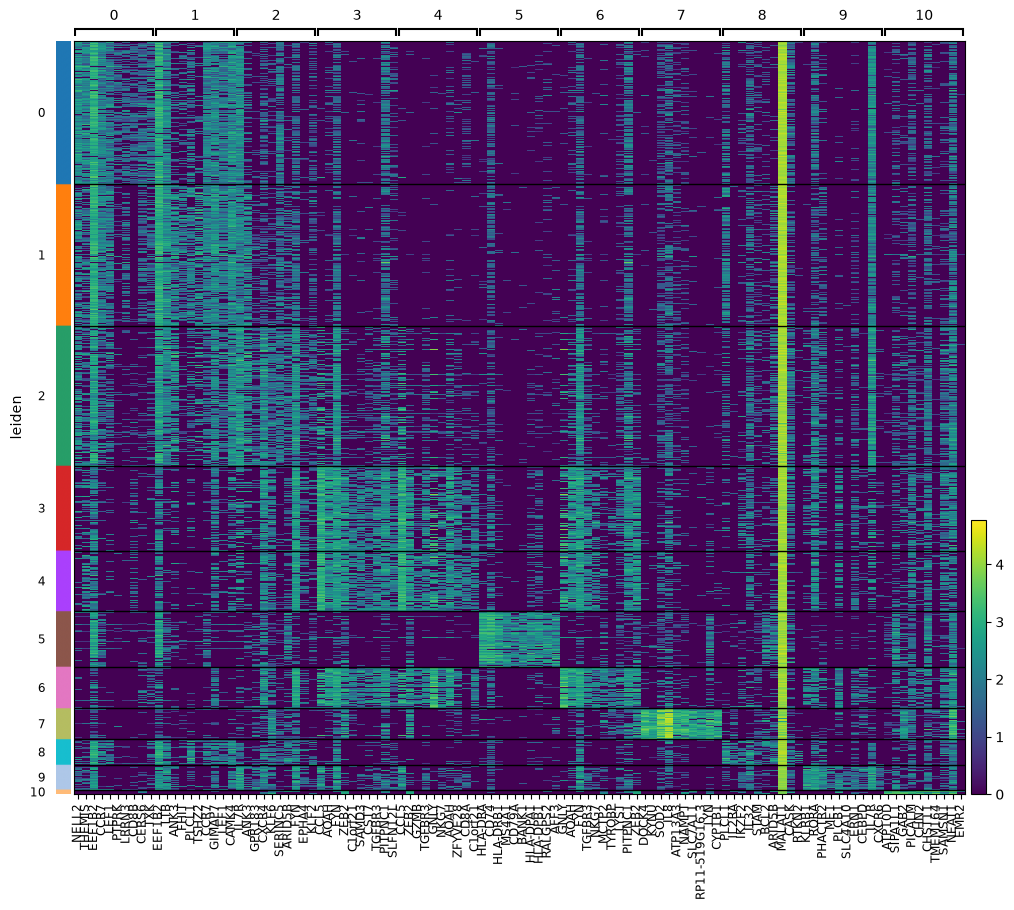


✓ Marker genes heatmap generated


In [14]:
# Heatmap of top marker genes
sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=10,
    key='rank_genes_leiden',
    groupby='leiden',
    show_gene_labels=True,
    figsize=(12, 10),
    dendrogram=False,
    show=True
)

print("\n✓ Marker genes heatmap generated")

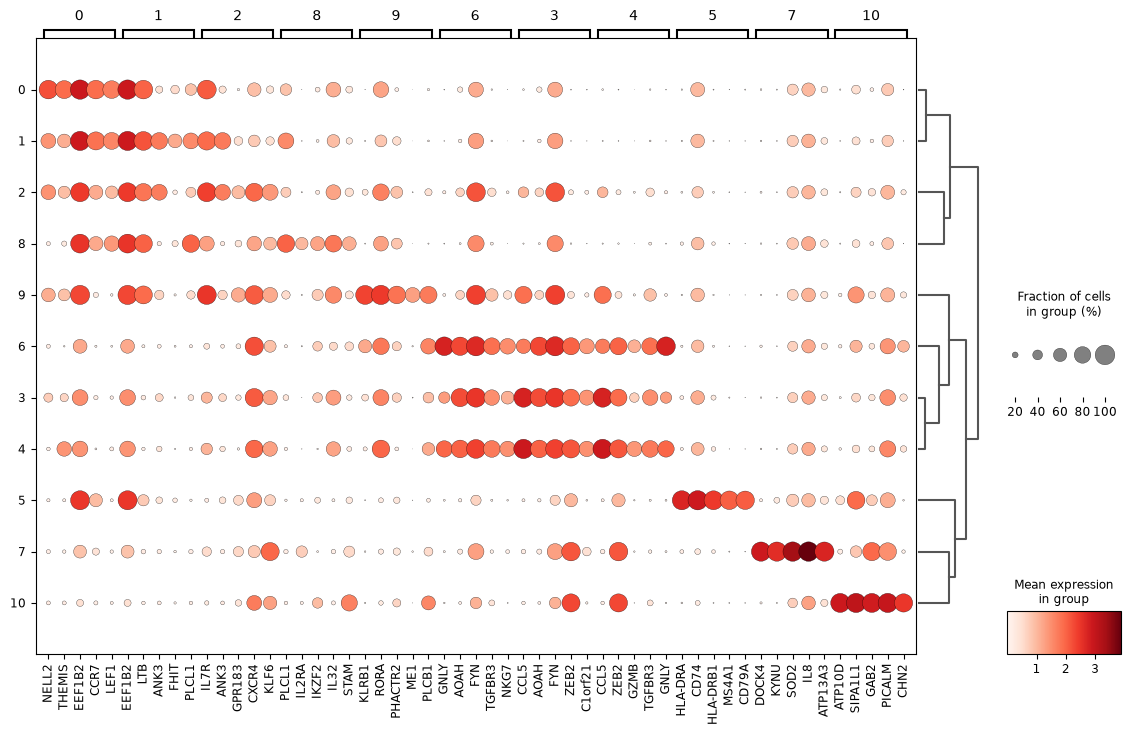


✓ Marker genes dot plot generated


In [15]:
# Dot plot of top marker genes
sc.tl.dendrogram(adata, groupby='leiden')
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=5,
    key='rank_genes_leiden',
    groupby='leiden',
    figsize=(14, 8),
    show=True
)

print("\n✓ Marker genes dot plot generated")

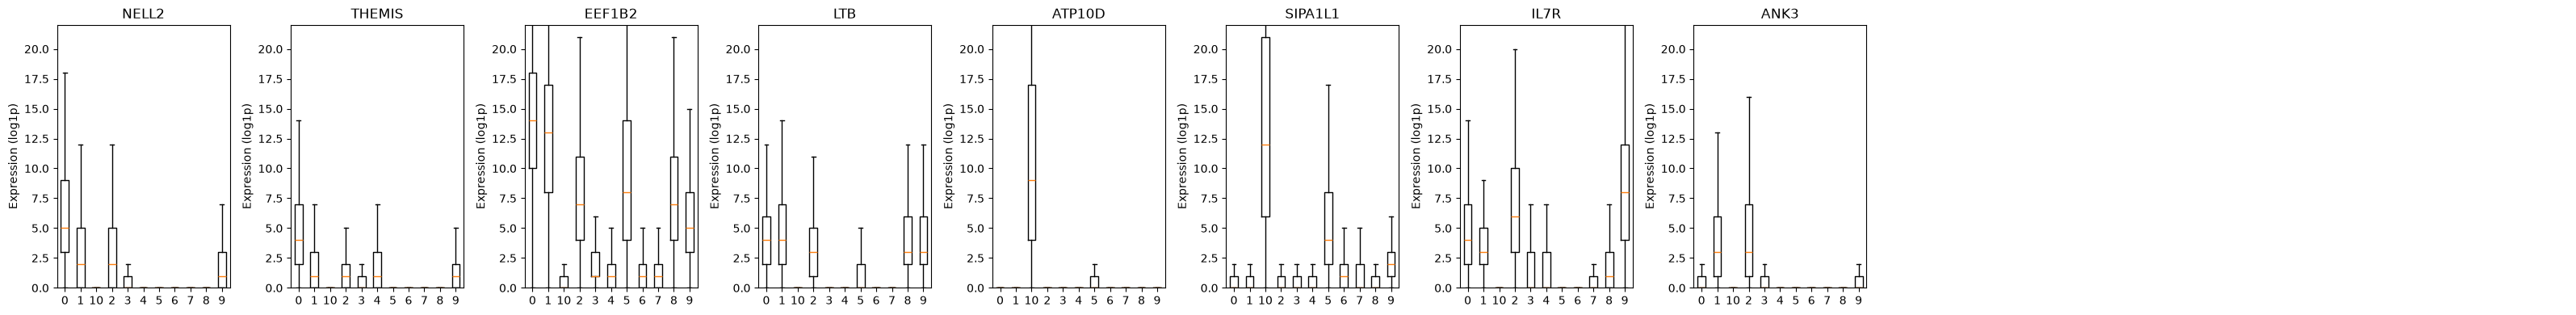


✓ Marker genes plots generated


In [16]:
# Get top 3 marker genes for all clusters for violin plots
top_genes = []
for cluster in sorted(adata.obs['leiden'].unique()):  # All clusters
    cluster_markers = marker_genes_df[
        marker_genes_df['group'] == cluster
    ].head(2)
    top_genes.extend(cluster_markers['names'].tolist())

# Remove duplicates while preserving order
top_genes = list(dict.fromkeys(top_genes))[:8]  # Limit to 8 genes

# Violin plot
if len(top_genes) > 0:
    genes = top_genes
    clusters = sorted(adata.obs['leiden'].unique())

    # Choose expression source:
    # - adata.X        → usually log1p-normalized
    # - adata.layers[normlog]    → if log1p stored
    # - adata.layers[] → e.g. 'counts'
    gene_idx = [adata.var_names.get_loc(g) for g in genes]
    X = adata.layers["counts"][:, gene_idx]

    # Convert sparse to dense if needed
    if hasattr(X, "toarray"):
        X = X.toarray()

    # Build expression DataFrame
    expr = pd.DataFrame(
        X,
        columns=genes,
        index=adata.obs['leiden']
    )

    # -----------------------------
    # Plot: boxplots in a grid
    # -----------------------------
    n_genes = len(genes)
    n_cols = len(adata.obs['leiden'].unique())
    n_rows = int(np.ceil(n_genes / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(32, 4* n_rows))
    axes = axes.flatten()

    # Optional: consistent y-axis across genes
    ymax = np.percentile(expr.values, 99)

    for ax, gene in zip(axes, genes):
        data = [expr.loc[cluster, gene].values for cluster in clusters]

        ax.boxplot(
            data,
            showfliers=False
        )
        ax.set_title(gene)
        ax.set_xticks(range(1, len(clusters) + 1))
        ax.set_xticklabels(clusters, rotation=0)
        ax.set_ylabel("Expression (log1p)")
        ax.set_ylim(0, ymax)

    # Hide unused panels
    for ax in axes[len(genes):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    print("\n✓ Marker genes plots generated")
else:
    print("\n⚠ No marker genes found for violin plot")

In [17]:
# from https://azimuth.hubmapconsortium.org/references/

azimuth_markers = {
    "Mono": ["CTSS", "FCN1", "NEAT1", "LYZ", "PSAP", "S100A9", "AIF1", "MNDA", "SERPINA1", "TYROBP"],
    "CD4 T": ["IL7R", "MAL", "LTB", "CD4", "LDHB", "TPT1", "TRAC", "TMSB10", "CD3D", "CD3G"],
    "CD8 T": ["CD8B", "CD8A", "CD3D", "TMSB10", "HCST", "CD3G", "LINC02446", "CTSW", "CD3E", "TRAC"],
    "NK": ["NKG7", "KLRD1", "TYROBP", "GNLY", "FCER1G", "PRF1", "CD247", "KLRF1", "CST7", "GZMB"],
    "B": ["CD79A", "RALGPS2", "CD79B", "MS4A1", "BANK1", "CD74", "TNFRSF13C", "HLA-DQA1", "IGHM", "MEF2C"],
    "other T": ["CD3D", "TRDC", "GZMK", "KLRB1", "NKG7", "TRGC2", "CST7", "LYAR", "KLRG1", "GZMA"],
    "DC": ["CD74", "HLA-DPA1", "HLA-DPB1", "HLA-DQA1", "CCDC88A", "HLA-DRA", "HLA-DMA", "CST3", "HLA-DQB1", "HLA-DRB1"]
}

In [18]:
for cell_type, genes in azimuth_markers.items():
    # Filter the list to only genes that exist in your adata (to avoid errors)
    valid_genes = [g for g in genes if g in adata.var_names]
    
    # Run the scoring
    sc.tl.score_genes(adata, gene_list=valid_genes, score_name=f'score_{cell_type}')

print("✓ All Azimuth scores calculated.")

✓ All Azimuth scores calculated.


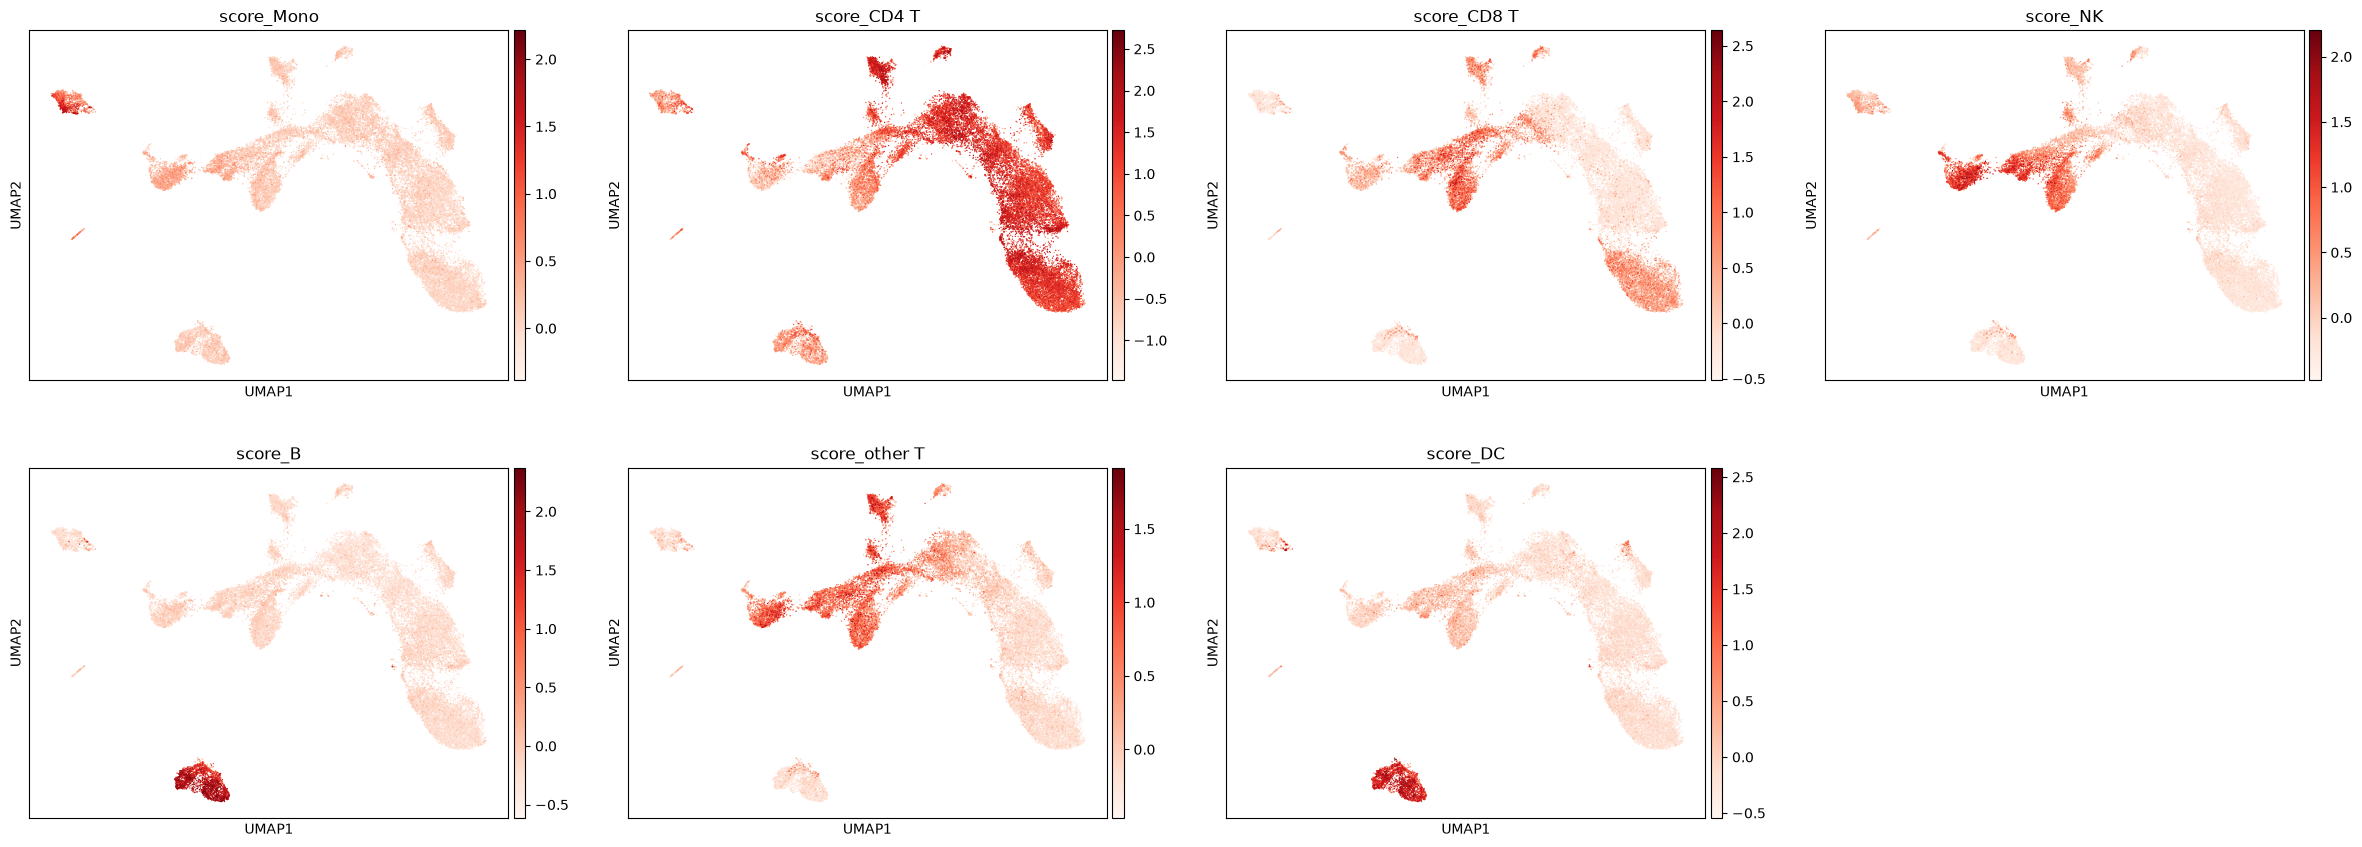

In [19]:
# Look at cell scores
sc.pl.umap(adata, color=[f'score_{cell_type}' for cell_type in azimuth_markers.keys()], cmap='Reds', show=False)
plt.savefig('results/cell_scores.png', bbox_inches='tight')

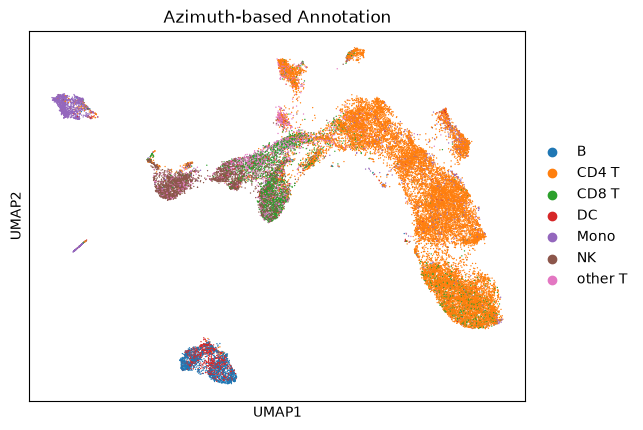

In [20]:
# List of the score columns we just created
score_columns = [f'score_{ct}' for ct in azimuth_markers.keys()]

# For every cell, find which score is the highest
adata.obs['predicted_type'] = adata.obs[score_columns].idxmax(axis=1)

# Clean up the names (remove 'score_')
adata.obs['predicted_type'] = adata.obs['predicted_type'].str.replace('score_', '')

# Plot the final result
sc.pl.umap(adata, color='predicted_type', title='Azimuth-based Annotation', show=False)

plt.savefig('results/azimuth_annotation.png', bbox_inches='tight')


In [21]:
# The "Tie-Breaker" Genes
tie_breakers = {
    'B-Cell Identity': ['CD79A', 'MS4A1', 'CD19'],
    'DC Identity': ['CST3', 'CLEC4C', 'LILRA4', 'CD1C'],
    'Shared (The Noise)': ['HLA-DRA', 'CD74']
}

sc.pl.stacked_violin(adata, tie_breakers, groupby='predicted_type', swap_axes=True, show=False)
plt.savefig('results/b_dc_diff.png', bbox_inches='tight')
plt.close()

In [22]:
from collections import Counter

# 1. Count how many times each gene appears across all Azimuth categories
all_genes = [gene for sublist in azimuth_markers.values() for gene in sublist]
gene_counts = Counter(all_genes)

# 2. Identify "Shared Genes" (appearing in 2 or more cell types)
# These are the genes like HLA-DRA and CD74 that cause the "speckling"
shared_genes = {gene for gene, count in gene_counts.items() if count > 1}

# 3. Create a "Cleaned" dictionary with ONLY unique markers
unique_azimuth_markers = {
    label: [gene for gene in genes if gene not in shared_genes]
    for label, genes in azimuth_markers.items()
}

# Print what we removed for your report documentation
print(f"Removed shared genes: {shared_genes}")

Removed shared genes: {'TMSB10', 'CD3D', 'CD3G', 'NKG7', 'TRAC', 'CST7', 'TYROBP', 'CD74', 'HLA-DQA1'}


In [23]:
for cell_type, genes in unique_azimuth_markers.items():
    # Filter the list to only genes that exist in your adata (to avoid errors)
    valid_genes = [g for g in genes if g in adata.var_names]
    
    # Run the scoring
    sc.tl.score_genes(adata, gene_list=valid_genes, score_name=f'score_{cell_type}')

print("✓ All Azimuth scores calculated.")

✓ All Azimuth scores calculated.


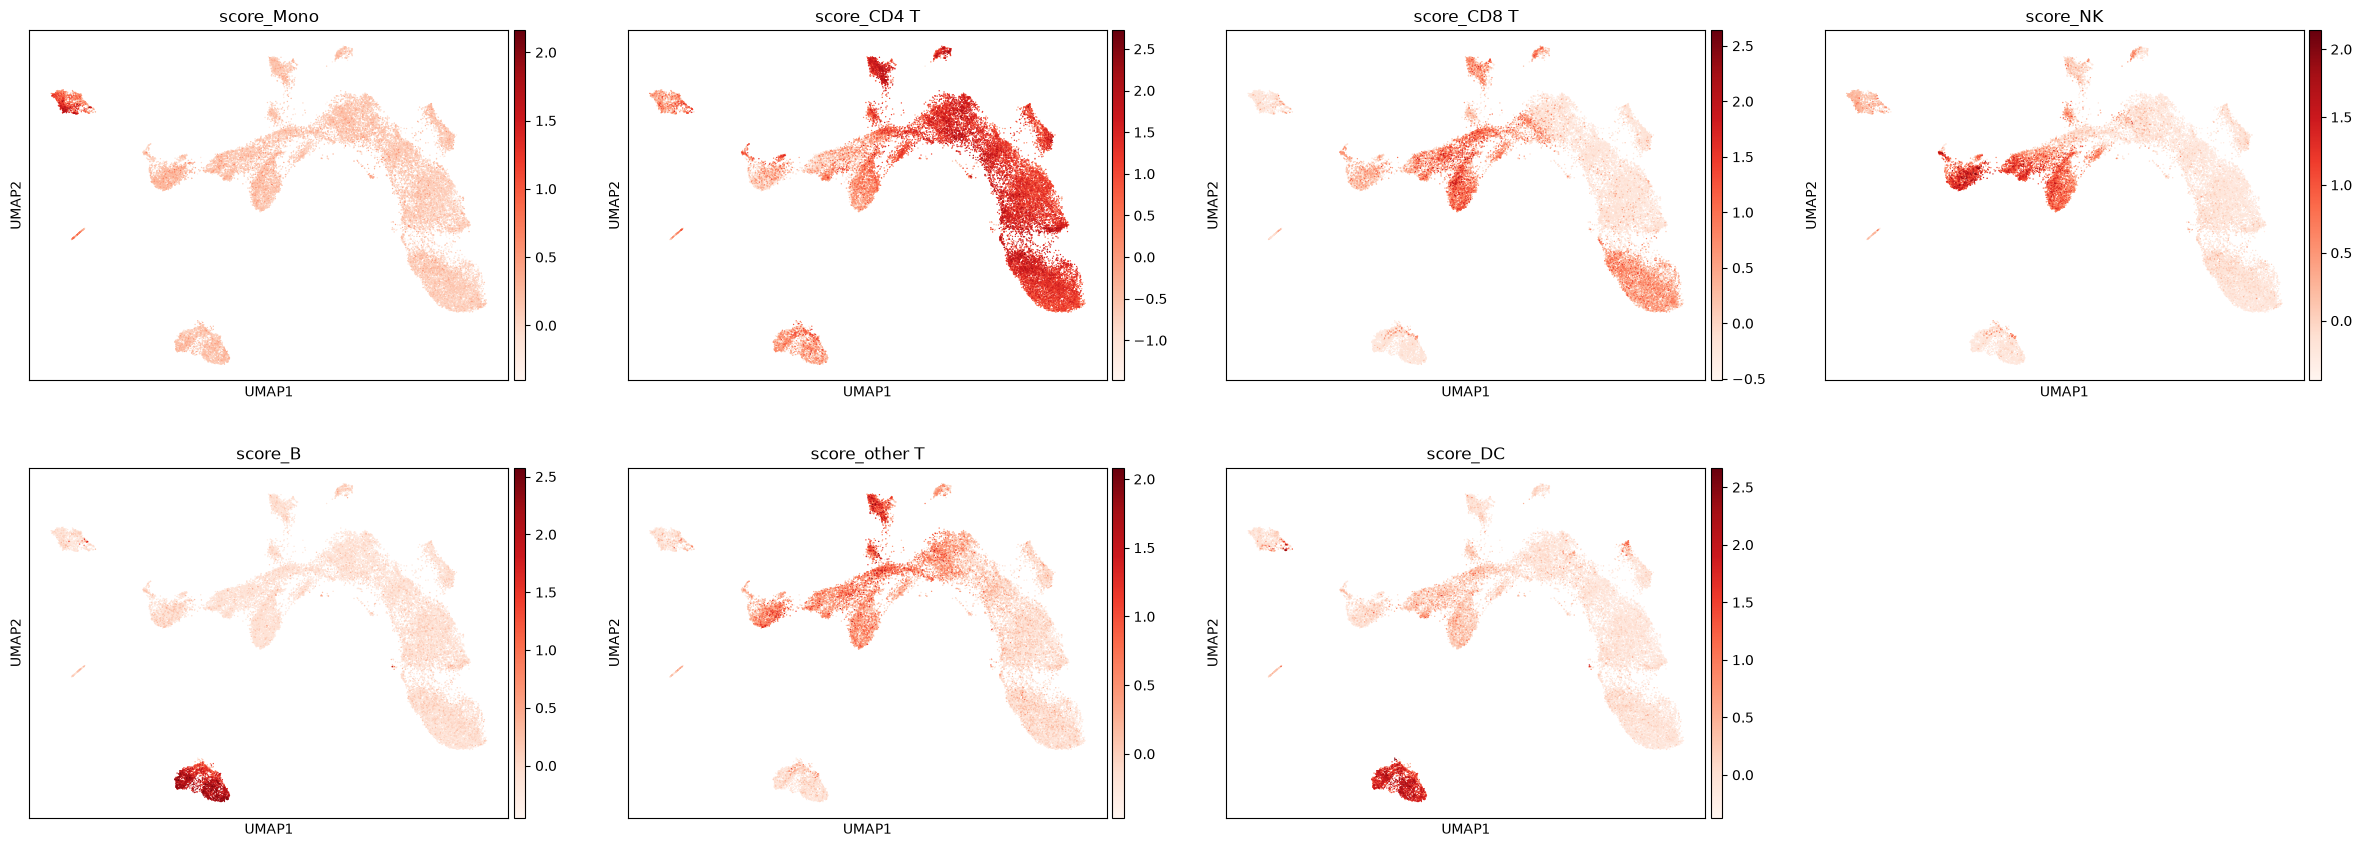

In [24]:
# Look at cell scores
sc.pl.umap(adata, color=[f'score_{cell_type}' for cell_type in unique_azimuth_markers.keys()], cmap='Reds', show=False)
plt.savefig('results/cell_scores_unique.png', bbox_inches='tight')

In [25]:
# List of the score columns we just created
score_columns = [f'score_{ct}' for ct in unique_azimuth_markers.keys()]

# For every cell, find which score is the highest
adata.obs['predicted_type'] = adata.obs[score_columns].idxmax(axis=1)

# Clean up the names (remove 'score_')
adata.obs['predicted_type'] = adata.obs['predicted_type'].str.replace('score_', '')

# Plot the final result
sc.pl.umap(adata, color='predicted_type', title='Azimuth-based Annotation', show=False)

plt.savefig('results/azimuth_annotation_unique.png', bbox_inches='tight')
plt.close()

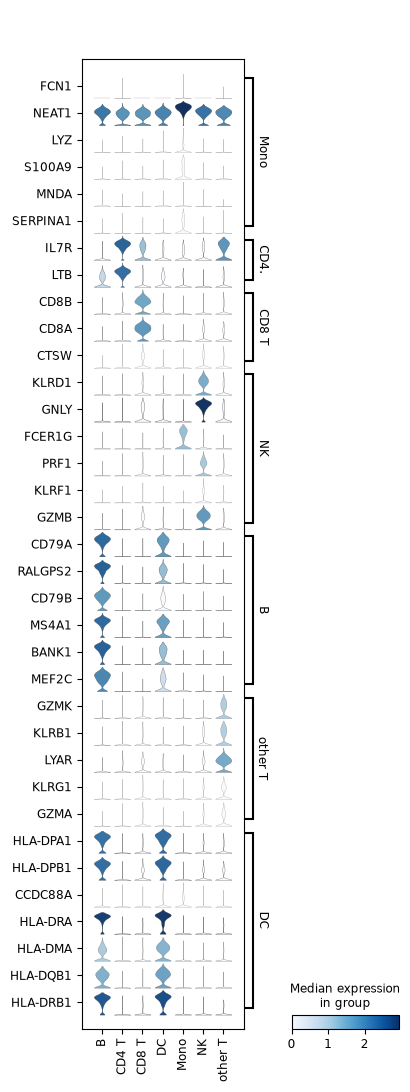

In [26]:
# 1. Get the list of genes actually present in your current adata object
available_genes = set(adata.var_names)

# 2. Filter the dictionary to remove genes that don't exist in your data
final_markers = {}
for cell_type, genes in unique_azimuth_markers.items():
    # Keep only genes that exist in the dataset
    valid = [g for g in genes if g in available_genes]
    if len(valid) > 0:
        final_markers[cell_type] = valid

sc.pl.stacked_violin(adata, final_markers, groupby='predicted_type', swap_axes=True, show=False)
plt.savefig('results/azimuth_violin.png', bbox_inches='tight')

In [27]:
# 1. Use the 'norm_log' layer we created (unscaled, non-negative)
# This ensures our averages are biologically meaningful
layer_to_use = "norm_log" 

# 2. Calculate the average expression of every gene for every cluster
# This is called 'Pseudobulking'
cluster_means = []
for cluster in adata.obs['leiden'].unique():
    cells_in_cluster = adata[adata.obs['leiden'] == cluster]
    # Calculate mean across the 'norm_log' layer
    mean_expr = cells_in_cluster.layers[layer_to_use].mean(axis=0)
    cluster_means.append(pd.Series(np.ravel(mean_expr), index=adata.var_names, name=cluster))

# Create a Cluster x Gene matrix
cluster_matrix = pd.concat(cluster_means, axis=1).T

In [28]:
# 1. Calculate a score for every Azimuth L1 category per cluster
group_scores = {}
for label, markers in azimuth_markers.items():
    # Only use genes that actually exist in our matrix
    valid_markers = [m for m in markers if m in cluster_matrix.columns]
    group_scores[label] = cluster_matrix[valid_markers].mean(axis=1)

# 2. Build a dataframe of the results
cluster_annotation_df = pd.DataFrame(group_scores)

# 3. Determine the "Winner" (Identity) for each cluster
cluster_annotation_df['final_label'] = cluster_annotation_df.idxmax(axis=1)
print(cluster_annotation_df)

        Mono     CD4 T     CD8 T        NK         B   other T        DC  \
2   0.290047  2.094733  0.169938  0.113102  0.117817  0.288977  0.147642   
4   0.244988  0.610723  0.818324  0.848890  0.143560  0.643592  0.310114   
3   0.320632  0.646180  0.602895  0.707301  0.160426  0.741712  0.328789   
0   0.211888  2.048357  0.494308  0.020841  0.154727  0.035279  0.156357   
1   0.217794  2.049634  0.022049  0.016532  0.155576  0.040276  0.146352   
8   0.255524  1.658143  0.021254  0.040119  0.139094  0.070726  0.203517   
6   0.502996  0.256883  0.280140  1.205980  0.162129  0.725619  0.187328   
5   0.303892  0.491197  0.038103  0.040717  1.963211  0.051237  1.842664   
9   0.270622  2.204547  0.475705  0.245112  0.141368  0.911312  0.168123   
7   1.036678  0.386825  0.032297  0.393483  0.116697  0.066154  0.199440   
10  0.536716  0.220278  0.035734  0.104059  0.067571  0.060069  0.132544   

   final_label  
2        CD4 T  
4           NK  
3      other T  
0        CD4 T  
1 

In [29]:
# Create the mapping dictionary from the automated results
cluster_to_type = cluster_annotation_df['final_label'].to_dict()

# Apply the labels to the full dataset
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_type)

In [30]:
sc.pl.dotplot(
    adata, 
    final_markers, 
    groupby='cell_type', 
    standard_scale='var', 
    title="Cluster-Level Identity Verification",
    show=False
)
plt.savefig('results/dot_plot_cluster.png', bbox_inches='tight')
plt.close()


In [31]:
sc.pl.umap(adata, color='cell_type', title='Azimuth-based Cluster-Level Annotation', show=False)
plt.savefig('results/umap_cluster.png', bbox_inches='tight')
plt.close()

I0000 00:00:1785518444.424954   19681 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-31 19:20:44.430671: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/jovan/Documents/gi/gi-2026/venv/lib/python3.12/site-packages/panhumanpy/ANNotate.py:1402: UserWarning: Ensure that the features metadata is indexed with gene names.
  warnings.warn(


Integer counts detected by panhumanpy.ANNotate : False
Log-normalization performed by panhumanpy.ANNotate: False
Query object:
    Total number of cells: 31767
    Total number of features: 2487
    Overlap w. feature reference: 1106 (~21%)

Splitting query data into 4 evaluation batch(es) of up to 
8192 cells.

Interpreting label predictions for consistent granularity at broad, medium, fine level(s).

Running model:


I0000 00:00:1785518450.613949   19977 service.cc:146] XLA service 0x753a340109d0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785518450.614003   19977 service.cc:154]   StreamExecutor device (0): Host, Default Version
2026-07-31 19:20:50.696256: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  4/256 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step

I0000 00:00:1785518451.436875   19977 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


256/256 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step
Extracting azimuth embeddings:
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


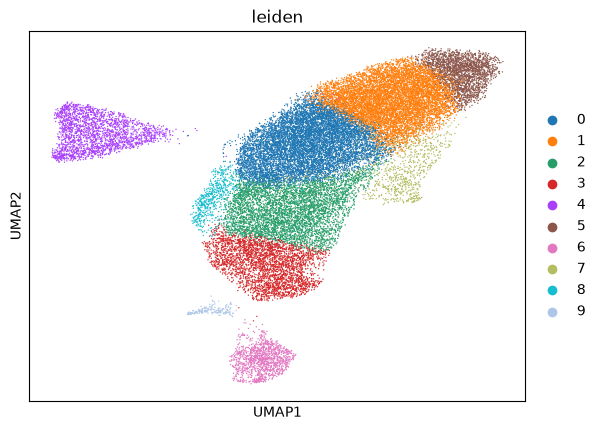

/home/jovan/Documents/gi/gi-2026/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.3, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Fri Jul 31 19:25:24 2026 Construct fuzzy simplicial set
Fri Jul 31 19:25:24 2026 Finding Nearest Neighbors
Fri Jul 31 19:25:24 2026 Building RP forest with 14 trees
Fri Jul 31 19:25:25 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	Stopping threshold met -- exiting after 3 iterations
Fri Jul 31 19:25:41 2026 Finished Nearest Neighbor Search
Fri Jul 31 19:25:43 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Fri Jul 31 19:26:17 2026 Finished embedding
✓ Azimuth annotation complete.


"\n\nsc.pl.umap(adata, color=['leiden', 'azimuth_type', 'azimuth_fine'], wspace=0.5, show=False)\nplt.savefig('results/leiden_azimuth.png')\nplt.close()\n\nsc.pl.embedding(adata, basis='azimuth_umap', color='azimuth_fine', title='Azimuth Reference Projection', show=False)\nplt.savefig('results/azimuth_umap.png')\nplt.close()\n\nprint(adata.var_names[:10])\n\nimport pandas as pd\n\n# Create a cross-tabulation of your Leiden clusters vs Azimuth labels\ncomparison = pd.crosstab(adata.obs['leiden'], adata.obs['azimuth_type'], margins=True)\nprint(comparison)\n"

In [32]:

from panhumanpy import AzimuthNN

azimuth = AzimuthNN(adata, output_mode='detailed')
'''
'''
predictions = azimuth.cells_meta
adata.obs['azimuth_type'] = predictions['azimuth_broad'] # Broad categories
adata.obs['azimuth_fine'] = predictions['azimuth_fine']   # Specific subsets

embeddings = azimuth.azimuth_embed()

# 2. Put them back into your adata
adata.obsm['X_azimuth'] = embeddings

# 3. Run neighbors and Leiden on the AI's features, not your raw PCA
sc.pp.neighbors(adata, use_rep='X_azimuth')
sc.tl.leiden(adata, resolution=0.6)
sc.tl.umap(adata)

# 4. Now look at your clusters. They should be MUCH cleaner.
sc.pl.umap(adata, color='leiden')

# 3. Add the Azimuth UMAP coordinates to your object
# This allows you to show your cells in the "Reference Space"
adata.obsm['X_azimuth_umap'] = azimuth.azimuth_umap()

print("✓ Azimuth annotation complete.")
'''

sc.pl.umap(adata, color=['leiden', 'azimuth_type', 'azimuth_fine'], wspace=0.5, show=False)
plt.savefig('results/leiden_azimuth.png')
plt.close()

sc.pl.embedding(adata, basis='azimuth_umap', color='azimuth_fine', title='Azimuth Reference Projection', show=False)
plt.savefig('results/azimuth_umap.png')
plt.close()

print(adata.var_names[:10])

import pandas as pd

# Create a cross-tabulation of your Leiden clusters vs Azimuth labels
comparison = pd.crosstab(adata.obs['leiden'], adata.obs['azimuth_type'], margins=True)
print(comparison)
'''

In [33]:
cell_metadata = azimuth.cells_meta

print(cell_metadata)

                                                    full_hierarchical_labels  \
40nm_AAACCCAAGTGGACGT-1_0       Immune cell|Lymphoid cell|B cell|Plasma cell   
40nm_AAACCCAGTATCGTGT-1_0                                         Unassigned   
40nm_AAACCCAGTGCCTAAT-1_0         Immune cell|Lymphoid cell|T/NK cell|T cell   
40nm_AAACCCATCCCGAAAT-1_0                                         Unassigned   
40nm_AAACCCATCGTCACCT-1_0         Immune cell|Lymphoid cell|T/NK cell|T cell   
...                                                                      ...   
control_TTTGTTGGTCACAATC-1_3  Immune cell|Lymphoid cell|B cell|Memory B cell   
control_TTTGTTGTCAGAGTTC-1_3                                      Unassigned   
control_TTTGTTGTCCTGCTAC-1_3     Immune cell|Lymphoid cell|T/NK cell|NK cell   
control_TTTGTTGTCGCCAACG-1_3     Immune cell|Lymphoid cell|T/NK cell|NK cell   
control_TTTGTTGTCTTAATCC-1_3                                      Unassigned   

                             final_leve

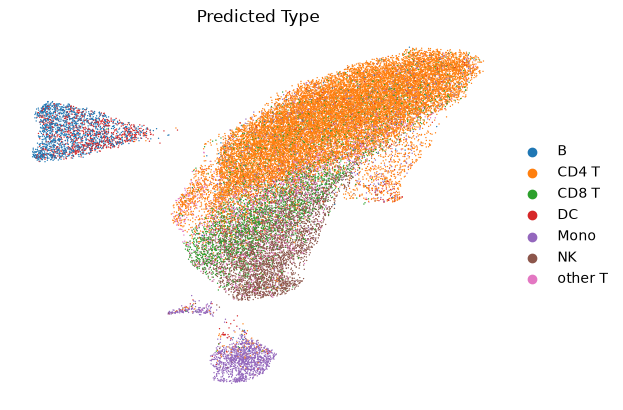

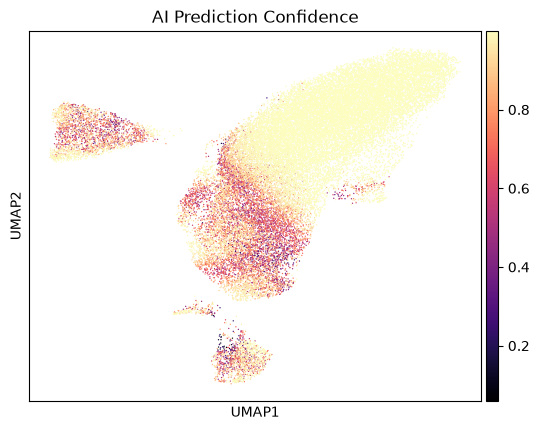

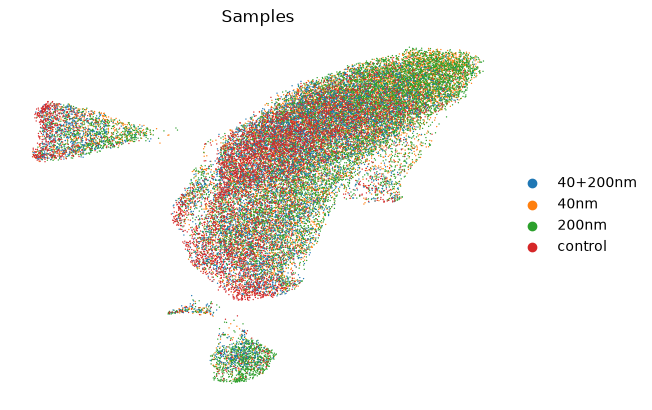

In [34]:
# Plot broad lineages vs. specific types
sc.pl.umap(adata, color=['predicted_type'], 
           title=['Predicted Type'],
           wspace=0.4, frameon=False, show=False)

plt.savefig('results/panhuman_umap_annotation.png', bbox_inches='tight')

# Plot the "Confidence" - This shows WHERE the AI was struggling
sc.pl.umap(adata, color='final_level_confidence', cmap='magma',
           title='AI Prediction Confidence', show=False)

plt.savefig('results/panhuman_umap_confidence.png', bbox_inches='tight')

# Plot broad lineages vs. specific types
sc.pl.umap(adata, color='sample_id',
           title=['Samples'],
           wspace=1, frameon=False, show=False)

plt.savefig('results/panhuman_umap_by_sample.png', bbox_inches='tight')

Cells remaining: 23113 out of 31767


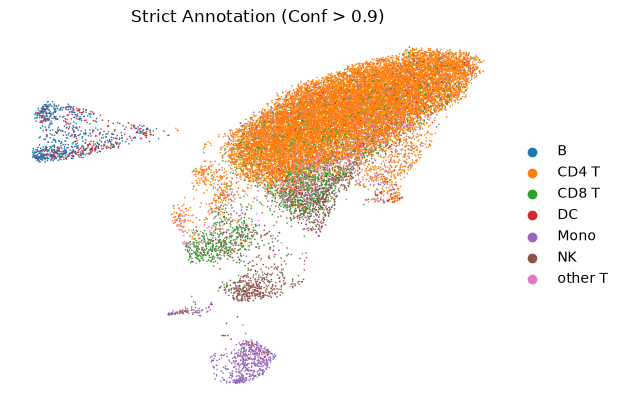

In [35]:
# 1. Create a temporary subset of high-confidence cells
adata_high = adata[adata.obs['final_level_confidence'] > 0.9].copy()

print(f"Cells remaining: {adata_high.n_obs} out of {adata.n_obs}")

# 2. Plot only these cells
sc.pl.umap(
    adata_high, 
    color='predicted_type', 
    title='Strict Annotation (Conf > 0.9)',
    frameon=False,
    show=False
)
plt.savefig('results/panhuman_umap_high_confidence_only.png', bbox_inches='tight')
plt.show()

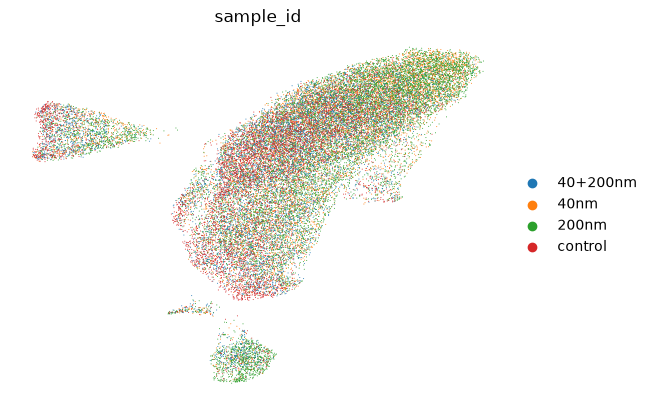

In [36]:
# Create a 2x2 grid comparing all conditions
sc.pl.umap(
    adata, 
    color='sample_id',
    ncols=2, 
    size=2,
    frameon=False,
    show=False
)

plt.savefig('results/umap_sample_comparison_grid.png', bbox_inches='tight')
plt.show()

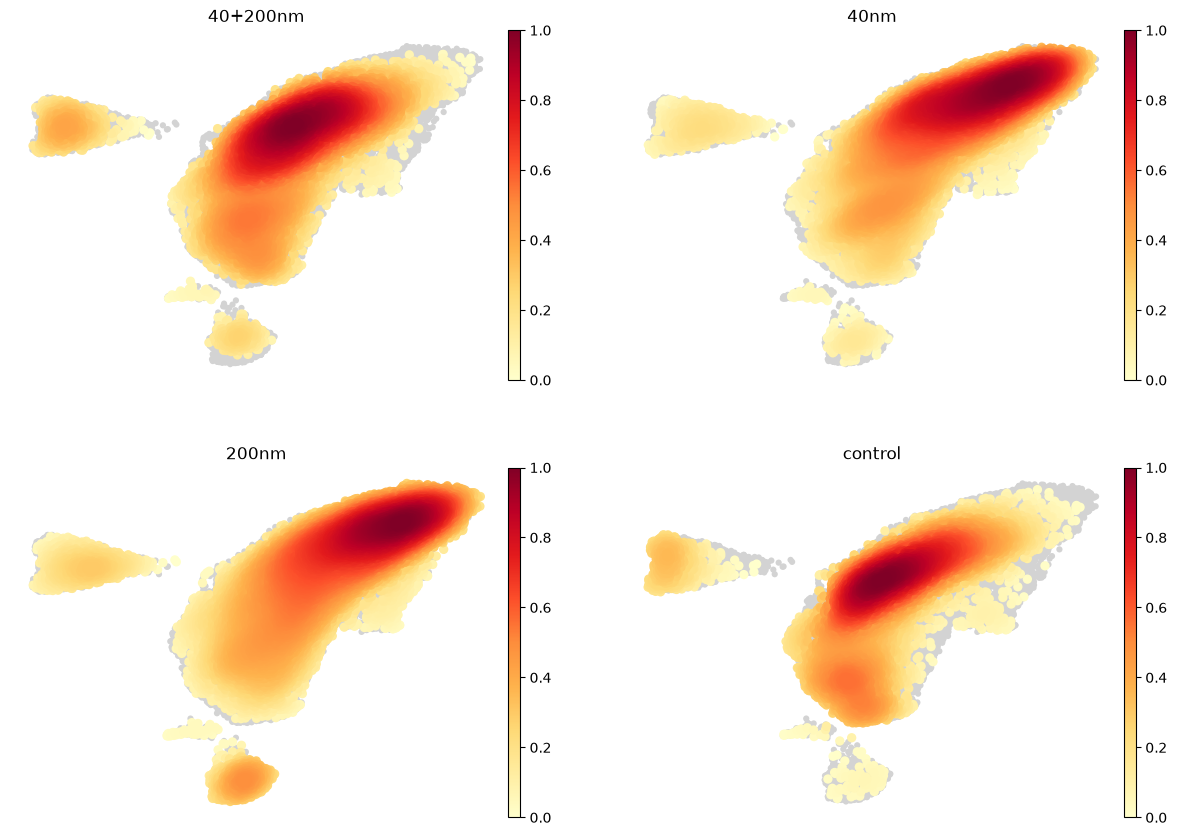

In [37]:
# This requires 'sc.tl.embedding_density'
sc.tl.embedding_density(adata, groupby='sample_id')

# Plot the density per sample
sc.pl.embedding_density(
    adata, 
    groupby='sample_id', 
    ncols=2,
    frameon=False,
    show=False
)

plt.savefig('results/umap_density_by_sample.png', bbox_inches='tight')
plt.show()

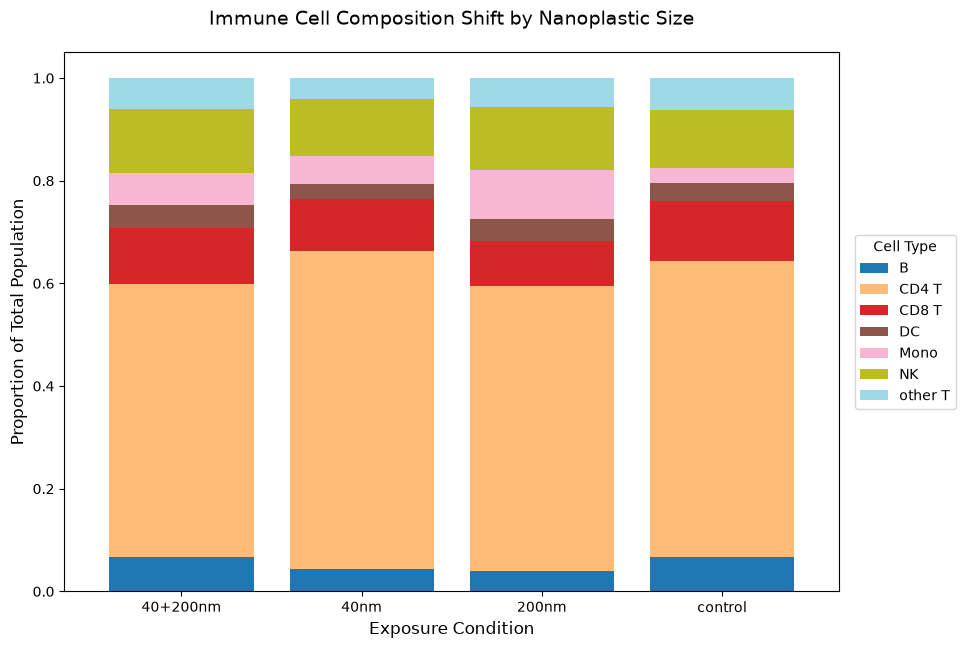

Composition Proportions:
predicted_type     B  CD4 T  CD8 T    DC  Mono     NK  other T
sample_id                                                     
40+200nm        6.66  53.27  10.95  4.32  6.20  12.49     6.10
40nm            4.33  62.06  10.10  2.96  5.38  11.07     4.11
200nm           3.92  55.64   8.76  4.32  9.48  12.34     5.55
control         6.71  57.72  11.58  3.53  2.90  11.29     6.26


In [38]:
import seaborn as sns

# 1. Create a contingency table (Counts of each cell type per sample)
# We use the 'predicted_type' or 'cell_type_final' column you created
counts = pd.crosstab(adata.obs['sample_id'], adata.obs['predicted_type'])

# 2. Normalize to proportions (0.0 - 1.0)
# This is critical because Sample 1 might have 8,000 cells and Sample 4 might have 6,000.
# Dividing by the sum of the row makes them comparable.
proportions = counts.div(counts.sum(axis=1), axis=0)

# 3. Create the Stacked Bar Chart
# We use a distinct colormap ('tab20' or 'Set3') to make cell types easy to distinguish
ax = proportions.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='tab20', width=0.8)

# 4. Professional Formatting
plt.title('Immune Cell Composition Shift by Nanoplastic Size', fontsize=14, pad=20)
plt.ylabel('Proportion of Total Population', fontsize=12)
plt.xlabel('Exposure Condition', fontsize=12)
plt.xticks(rotation=0) # Keeps 'control', '40nm' etc. horizontal

# Move legend outside so it doesn't cover the bars
plt.legend(title='Cell Type', bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)

# 5. Save the results
plt.savefig('results/composition_stacked_bar.png', bbox_inches='tight', dpi=300)
plt.show()

# 6. Display the raw numbers (useful for your report text)
print("Composition Proportions:")
print((proportions * 100).round(2)) # Show as percentages

In [39]:
# Calculate Fold Change relative to 'control'
control_row = proportions.loc['control']
fold_change = proportions.div(control_row, axis=1)

print("\nFold Change relative to Control (Value of 2.0 = Double the cells):")
print(fold_change.round(2))


Fold Change relative to Control (Value of 2.0 = Double the cells):
predicted_type     B  CD4 T  CD8 T    DC  Mono    NK  other T
sample_id                                                    
40+200nm        0.99   0.92   0.95  1.22  2.14  1.11     0.97
40nm            0.64   1.08   0.87  0.84  1.85  0.98     0.66
200nm           0.58   0.96   0.76  1.22  3.27  1.09     0.89
control         1.00   1.00   1.00  1.00  1.00  1.00     1.00


In [40]:
# List all columns to find the confidence key
print(adata.obs.columns.tolist())

['full_hierarchical_labels', 'final_level_labels', 'final_level_confidence', 'full_consistent_hierarchy', 'level_1_labels', 'level_2_labels', 'level_3_labels', 'level_4_labels', 'level_5_labels', 'level_6_labels', 'level_7_labels', 'level_8_labels', 'azimuth_broad', 'azimuth_medium', 'azimuth_fine', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.3', 'seurat_clusters', 'predicted.id', 'prediction.score.CD14..monocyte', 'prediction.score.Dendritic.cell', 'prediction.score.Cytotoxic.T.cell', 'prediction.score.Plasmacytoid.dendritic.cell', 'prediction.score.B.cell', 'prediction.score.Natural.killer.cell', 'prediction.score.CD4..T.cell', 'prediction.score.Megakaryocyte', 'prediction.score.Unassigned', 'prediction.score.max', 'predicted.celltype.score', 'predicted.celltype', 'sample_id', 'condition', 'prediction.score.CD16..monocyte', 'sample_batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'score_Mono', 'score_CD4 T', 'score_CD8 T', 'score_

In [41]:
# Calculate stats per condition
confidence_stats = adata.obs.groupby('sample_id')['final_level_confidence'].agg(['mean', 'median', 'std'])

print("AI Confidence Stats by Sample:")
print(confidence_stats.round(3))

AI Confidence Stats by Sample:
            mean  median    std
sample_id                      
40+200nm   0.875   0.987  0.187
40nm       0.914   0.999  0.166
200nm      0.906   0.999  0.173
control    0.881   0.979  0.174


/tmp/ipykernel_19681/2459592327.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  confidence_stats = adata.obs.groupby('sample_id')['final_level_confidence'].agg(['mean', 'median', 'std'])


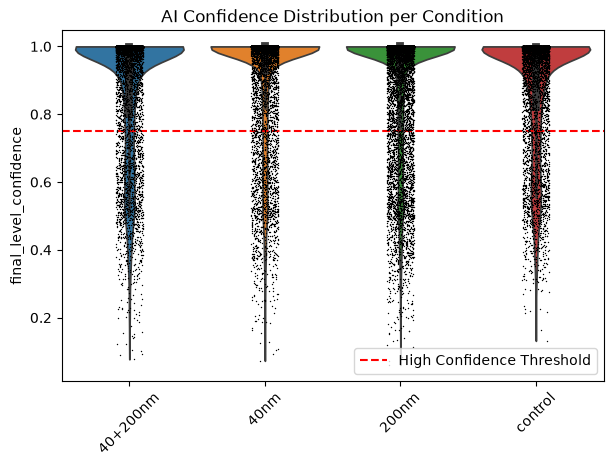

In [42]:
# Use Scanpy's built-in violin plot to compare distributions
sc.pl.violin(
    adata, 
    keys='final_level_confidence', 
    groupby='sample_id', 
    inner='box', 
    rotation=45,
    show=False
)

plt.title('AI Confidence Distribution per Condition')
plt.axhline(y=0.75, color='red', linestyle='--', label='High Confidence Threshold')
plt.legend()
plt.savefig('results/confidence_by_sample.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_19681/1768639015.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cross_check = adata.obs.groupby(['sample_id', 'predicted_type'])['final_level_confidence'].mean().unstack()


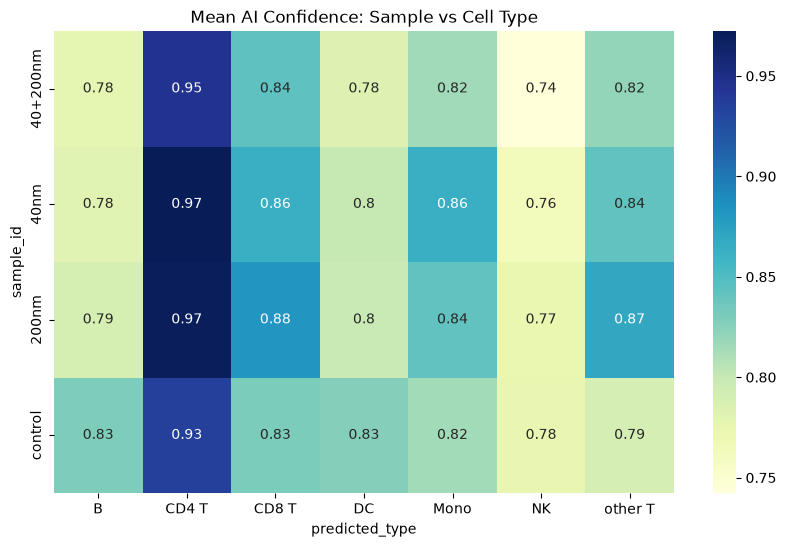

In [43]:
# Check which cell types the AI is struggling with under exposure
cross_check = adata.obs.groupby(['sample_id', 'predicted_type'])['final_level_confidence'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(cross_check, annot=True, cmap='YlGnBu')
plt.title('Mean AI Confidence: Sample vs Cell Type')
plt.show()

In [ ]:
import gseapy as gp
import os

# Create folders for outputs
os.makedirs('results/DE_tables', exist_ok=True)
os.makedirs('results/Pathways', exist_ok=True)

# Define the cell types you want to analyze
cell_types = adata.obs['predicted_type'].unique()

# The conditions to compare against control
conditions = ['40nm', '200nm', '40+200nm']

# Dictionary to store results for Task 6
de_results_master = {}

for ct in cell_types:
    print(f"--- Analyzing {ct} ---")
    
    # 1. Subset to the specific cell type
    subset = adata[adata.obs['predicted_type'] == ct].copy()
    
    # 2. Run DE Analysis (Wilcoxon) using our unscaled log-layer
    sc.tl.rank_genes_groups(
        subset, 
        groupby='sample_id', 
        reference='control', 
        method='wilcoxon', 
        layer='norm_log',
        use_raw=False
    )
    
    for cond in conditions:
        # 3. Extract results into a DataFrame
        de_df = sc.get.rank_genes_groups_df(subset, group=cond)
        
        # 4. Filter for SIGNIFICANT genes (p-adj < 0.05 and logFC > 1)
        # Note: LogFC > 1 means the gene is at least 2x more expressed in the exposed sample
        sig_genes = de_df[(de_df['pvals_adj'] < 0.05) & (de_df['logfoldchanges'] > 1)]
        
        # Save table
        sig_genes.to_csv(f'results/DE_tables/{ct}_{cond}_vs_control.csv')
        
        # Store gene list for Task 6 later
        de_results_master[f"{ct}_{cond}"] = sig_genes['names'].tolist()
        
        # 5. Pathway Enrichment (if we found at least 5 genes)
        if len(sig_genes) >= 5:
            print(f"Running Enrichment for {ct} in {cond}...")
            enr = gp.enrichr(
                gene_list=sig_genes['names'].tolist(),
                gene_sets=['GO_Biological_Process_2023', 'KEGG_2021_Human', 'Reactome_2022'],
                organism='human',
                outdir=None # Keeps it in memory
            )
            
            # Save top 10 pathways
            enr.results.head(10).to_csv(f'results/Pathways/{ct}_{cond}_pathways.csv')

print("\n✓ Task 5 Computation Complete.")

--- Analyzing CD4 T ---
Running Enrichment for CD4 T in 40nm...


ValueError: Invalid organism 'Human'. Valid options are: c. elegans, caenorhabditis elegans, celegans, d. melanogaster, d. rerio, danio rerio, drosophila, drosophila melanogaster, enrichr, fish, fly, h. sapiens, homo sapiens, hs, hsapiens, human, m. musculus, mm, mouse, mus musculus, nematode, s. cerevisiae, saccharomyces, saccharomyces cerevisiae, worm, yeast, zebrafish